In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from pfi.utils.data import load_data, X_from_snapshots, assign_OT, compute_correlations
from pfi import make_score_estimator, make_flow_estimator
from pfi.flow.models import *
from pfi.score import freeze_dsm_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

/mnt/home/vchardes/.local/share/venvs/score/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


device(type='cuda')

In [2]:
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

nsamples = 6000

genes = ['gata1','fli1','klf1','gata2','gfi1','gfi1b','runx1','tal1','jun','spi1','zfpm1','lmo2','etv6','erg','cebpa',\
         'meis1','sall4','myc','foxo3','zbtb7a', 'nfe2','stat3','mef2c'] #'nanog', 

samples, times, ind_array, cell_types = load_data(
    "natcomm",
    nsamples=nsamples,
    genes=genes,
    time_key='day',
    cell_type_key='cell_type',
    seed=seed,
    max_tot_counts=200,
    normalize=False,
)

X = X_from_snapshots([samples[k] for k in range(samples.shape[0])], times)
ndim = X.shape[1] - 1
print('X shape:', X.shape, 'ndim:', ndim, 'times:', times)




[fetch] using cached file: /mnt/home/vchardes/pfi_data/10XChromiumV3_10.1038_s41467-021-27159-x_10.5281_zenodo.5291737.h5ad
[load_data] removed 586 cells outside total-count range [0.0, 200] (1.10% of total cells) before subsampling.
['Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2', 'Mk1', 'Mk2']
X shape: (36000, 24) ndim: 23 times: [ 0  2  4  6  8 11]


In [3]:
score_reg = make_score_estimator(ndim, 
                                 params=None,
                                 device=device,
                                 seed=seed)
score_reg.fit(X)


DSM: 100%|██████████| 4000/4000 [00:39<00:00, 102.52it/s, loss=1.167e+01, lr=5.00e-05]


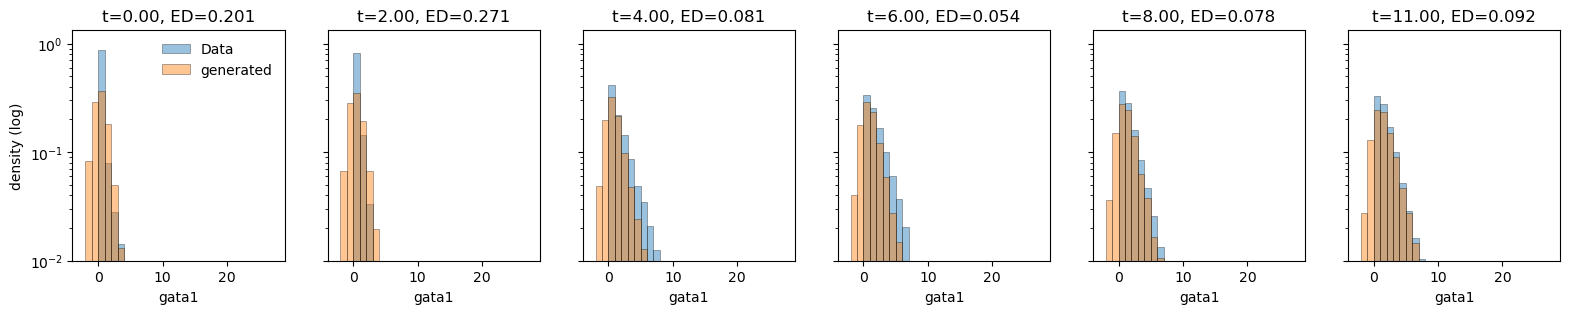

In [4]:
# Validate score model: histogram overlays (generated vs true) for gata1 with shared axes

times_eval = np.unique(X[:, -1])
X_gen = score_reg.sample(X)
ed_score = score_reg.score(X)

gata1_idx = genes.index('gata1')

values_true = []
values_pred = []
for t in times_eval:
    xk = X[X[:, -1] == t]
    xk_gen = X_gen[X_gen[:, -1] == t]
    values_true.append(xk[:, gata1_idx])
    values_pred.append(xk_gen[:, gata1_idx])

x_min = float(np.floor(min(np.min(v) for v in values_true + values_pred)))
x_max = float(np.ceil(max(np.max(v) for v in values_true + values_pred)))
bins = np.arange(x_min, x_max + 2, 1)

fig, axes = plt.subplots(1, len(times_eval), figsize=(3.2 * len(times_eval), 3), sharex=True, sharey=True)
if len(times_eval) == 1:
    axes = [axes]

for k, t in enumerate(times_eval):
    ax = axes[k]
    ax.hist(
        values_true[k],
        bins=bins,
        alpha=0.45,
        label='Data',
        color='tab:blue',
        density=True,
        edgecolor='black',
        linewidth=0.5,
    )
    ax.hist(
        values_pred[k],
        bins=bins,
        alpha=0.45,
        label='generated',
        color='tab:orange',
        density=True,
        edgecolor='black',
        linewidth=0.5,
    )
    ax.set_title(f't={t:.2f}, ED={ed_score[k]:.3f}')
    ax.set_xlabel('gata1')
    ax.set_yscale('log')

for ax in axes:
    ax.set_xlim(x_min, x_max)

y_max = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(1e-2, y_max)

axes[0].set_ylabel('density (log)')
axes[0].legend(frameon=False)
plt.show()


In [5]:
lx = 0.3
base_f_kwargs = {'lx': lx}
model_classes = {
    'cle': (CLEFlow, base_f_kwargs),
    'positive-cle': (PositiveCLEFlow, base_f_kwargs),
    'additive': (AdditiveFlow, base_f_kwargs),
    'multiplicative': (MultiplicativeFlow, base_f_kwargs),
    'autonomous-ode': (AutonomousODEFlow, base_f_kwargs),
    'additive-gradient': (AdditiveGradientFlow, base_f_kwargs),
    'na-additive-gradient': (NonAutonomousAdditiveGradientFlow, {}),
    'ode': (ODEFlow, base_f_kwargs),
}

model_names = list(model_classes.keys())

score = freeze_dsm_score(score_reg.model_, 
                         noise_lvl=score_reg.noise_lvl_)

flow_regs = {}
for model_name in model_names:
    f_model, f_model_kwargs = model_classes[model_name]
    flow_params = {}
    flow_params['f_model'] = f_model
    flow_params['f_model_kwargs'] = dict(f_model_kwargs)
    flow_reg = make_flow_estimator(ndim=ndim, 
                                    params=flow_params, 
                                    device=device, 
                                    seed=seed,
                                    score=score)
    flow_reg.fit(X)
    flow_regs[model_name] = flow_reg




pfm: 100%|██████████| 2000/2000 [00:09<00:00, 210.41it/s, loss=9.794e+01, lr=1.00e-05]


In [6]:
# Run inferred models from NatComm t0 to the last train time
train_times = np.asarray(times, dtype=float)
t0_train = float(train_times[0])
tT_train = float(train_times[-1])
X0_train = np.hstack([samples[0, :, :ndim], t0_train * np.ones((samples.shape[1], 1))])

gen_natcomm_last = {}
for model_name, reg in flow_regs.items():
    gen_natcomm_last[model_name] = reg.sample(
        X0_train,
        Dt=tT_train,
        stoch=True,
        dt=0.005,
        pos=True,
    )

t_ex = np.sort(np.unique(X[:, -1]))
t0 = t_ex[0]
X0 = X[np.isclose(X[:, -1], t0)]

# Precompute predictions per method/time
pred_by_model = {m: [] for m in flow_regs.keys()}
for model_name, reg in flow_regs.items():
    for k, tk in enumerate(t_ex):
        if k == 0:
            gen = X0[:, :ndim]
        else:
            dtk = float(tk - t0)
            gen = reg.sample(X0, Dt=dtk, stoch=True, dt=0.005, pos=True)
        pred_by_model[model_name].append(gen[:, gata1_idx])



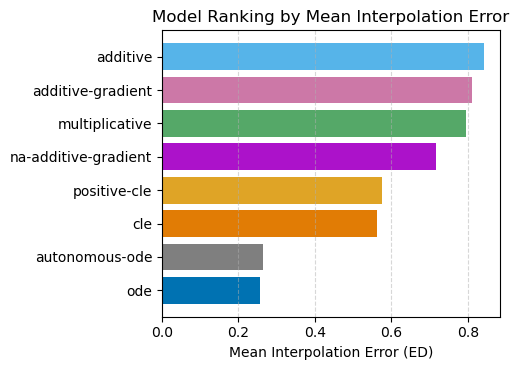

In [7]:
# Stochastic interpolation
import matplotlib.pyplot as plt

t_ex = np.sort(np.unique(X[:, -1]))
t0_ex = t_ex[0]
X0_ex = X[np.isclose(X[:, -1], t0_ex)]
interp_errors = {}
for name, reg in flow_regs.items():
    ed = []
    for ty in t_ex[1:]:
        y_t = X[np.isclose(X[:, -1], ty)]
        ed.append(reg.score(X0_ex, y_t, stoch=True, pos=True, dt=5e-3)[0])
    interp_errors[name] = np.asarray(ed)

mean_interp_errors = {name: float(np.mean(ed)) for name, ed in interp_errors.items()}

sorted_items = sorted(mean_interp_errors.items(), key=lambda x: x[1])
methods_sorted, means_sorted = zip(*sorted_items)
base_colors = {
    'cle': '#E17C05',
    'additive': '#56B4E9',
    'multiplicative': '#55A868',
    'autonomous-ode': '#7F7F7F',
    'ode': '#0072B2',
    'additive-gradient': '#CC78A7',
    'positive-cle': "#DFA426",
    'na-additive-gradient': "#AC12CA",
    'trajnet+': "#3200BB",
    'prescient+': "#26DF9281",
}

colors_sorted = [base_colors.get(m, '#7F7F7F') for m in methods_sorted]

fig, ax = plt.subplots(figsize=(5.2, 3.8))
ax.barh(methods_sorted, means_sorted, color=colors_sorted)
ax.set_xlabel('Mean Interpolation Error (ED)')
ax.set_title('Model Ranking by Mean Interpolation Error')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



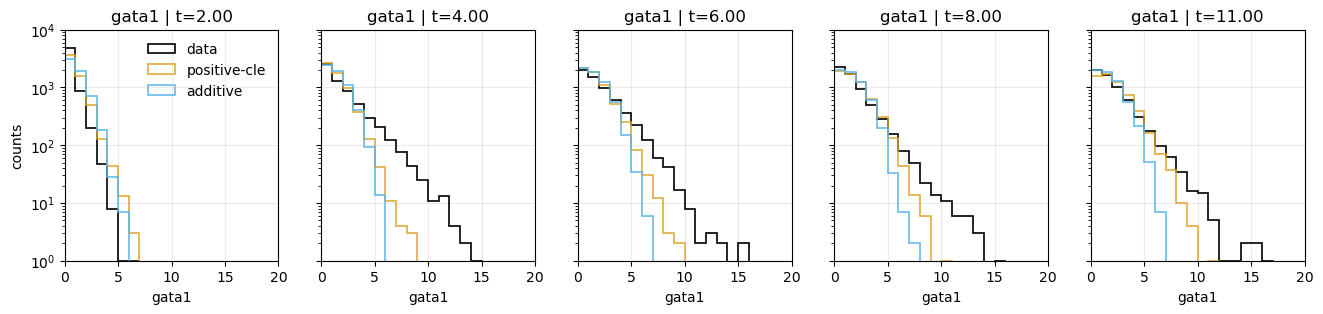

In [8]:
# NatComm overlay histograms of predicted vs true gata1 at all times (one subplot per time)
import matplotlib.pyplot as plt
show = ['positive-cle', 'trajnet+', 'additive']


gata1_idx = genes.index('gata1')
xmin = 0
xmax = 20
bins = np.arange(xmin, xmax, 1)

n_times = len(t_ex[1:])
fig, axes = plt.subplots(1, n_times, figsize=(3.2 * n_times, 3.0), sharex=True, sharey=True)

for ax, (k, tk) in zip(axes, enumerate(t_ex[1:], start=1)):
    true_vals = X[np.isclose(X[:, -1], tk)][:, gata1_idx]

    ax.hist(
        true_vals,
        bins=bins,
        density=False,
        histtype='step',
        linewidth=1.2,
        color='black',
        label='data',
    )

    for model_name in flow_regs.keys():
        if model_name in show:
            cfg = base_colors.get(model_name)
            ax.hist(
                pred_by_model[model_name][k],
                bins=bins,
                density=False,
                color=cfg,
                histtype='step',
                linewidth=1.2,
                alpha=0.9,
                label=model_name,
            )

    ax.set_title(f'gata1 | t={tk:.2f}')
    ax.set_xlabel('gata1')
    ax.set_yscale('log')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin=1, ymax=1e4)
    ax.grid(alpha=0.25)

axes[0].set_ylabel('counts')
axes[0].legend(frameon=False)
#plt.tight_layout()
plt.show()



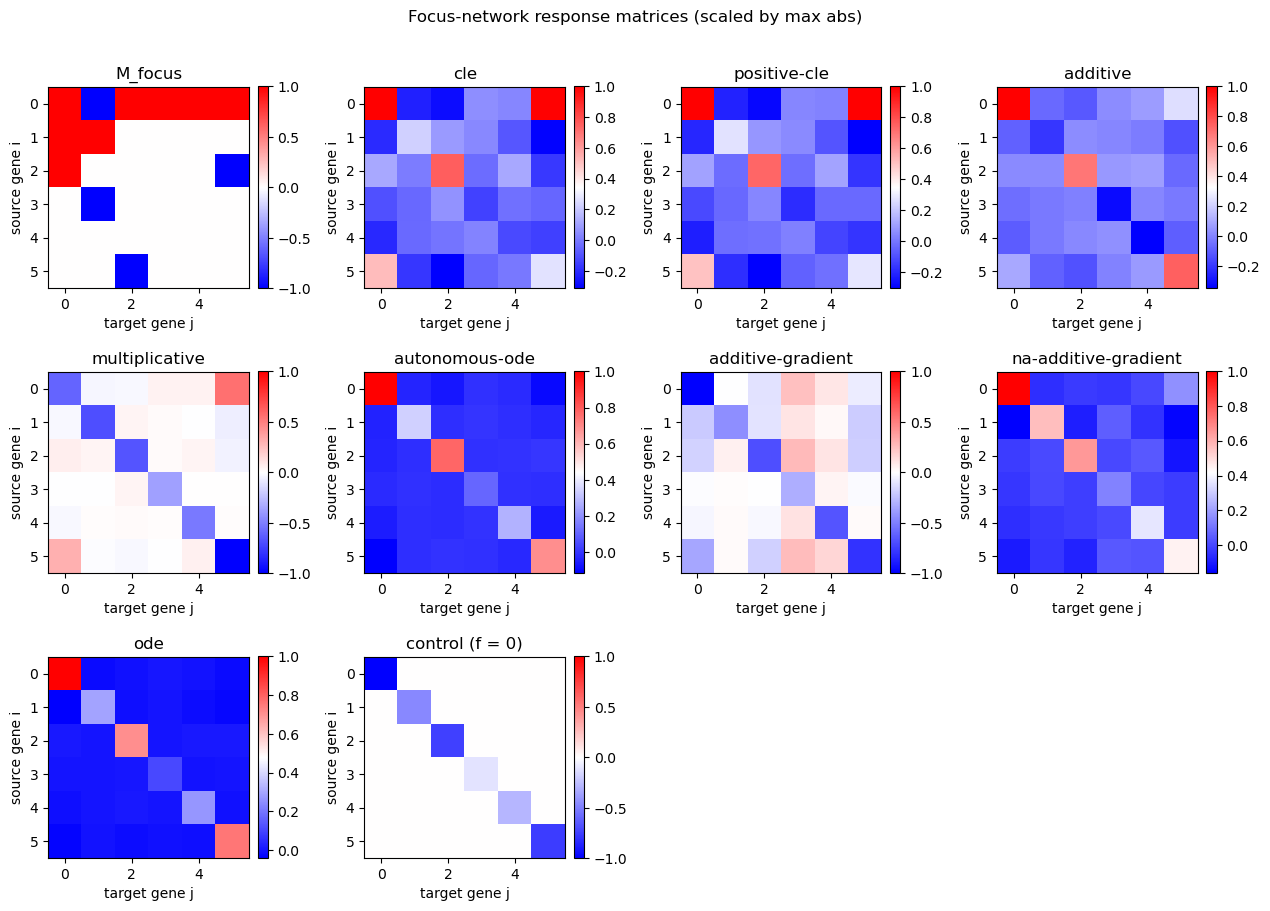

Cosine similarity with known matrix M (focus genes):
                       cle : 0.4135
              positive-cle : 0.4116
      na-additive-gradient : 0.3359
                       ode : 0.2428
                  additive : 0.2248
            autonomous-ode : 0.2097
            multiplicative : -0.0864
         additive-gradient : -0.2007
           control (f = 0) : -0.2706

AUPRC metrics (focus genes):
                    model | AP_edge | AP_pos | AP_neg | AP_signed
                       cle | 0.6005 | 0.5561 | 0.5312 | 0.5437
              positive-cle | 0.5816 | 0.5471 | 0.4917 | 0.5194
      na-additive-gradient | 0.5006 | 0.4291 | 0.3080 | 0.3686
            multiplicative | 0.4596 | 0.4745 | 0.2001 | 0.3373
                  additive | 0.4743 | 0.4156 | 0.2294 | 0.3225
                       ode | 0.4638 | 0.3989 | 0.2037 | 0.3013
            autonomous-ode | 0.4582 | 0.3329 | 0.1132 | 0.2230
         additive-gradient | 0.4437 | 0.2168 | 0.1516 | 0.1842
           control (

In [9]:
# Response matrix Delta, cosine similarity, and AUPRC with known HSC regulatory matrix M
from pfi.utils.data import get_hsc_network, evaluate_signed_network_auprc

M, network_genes = get_hsc_network(genes)

xis = np.linspace(0.5, 0.99, 10)
# subnetwork for the megakaryocytes
focus_genes = ['gata1', 'gata2', 'fli1', 'zfpm1', 'tal1', 'klf1']
focus_idx = np.array([genes.index(g) for g in focus_genes], dtype=int)
M_focus = M[np.ix_(focus_idx, focus_idx)]


def _scale_by_max_abs(A):
    amax = np.max(np.abs(A))
    return A if amax == 0 else A / amax


response_matrices = {}
cosine_similarity = {}
auprc_scores = {}
delta_focus_mats = {'M_focus': M_focus}

X_eval = np.asarray(X, dtype=np.float32)

for model_name, reg in flow_regs.items():
    ref_param = next(reg.flow_.parameters())
    X_eval_t = torch.as_tensor(X_eval, dtype=ref_param.dtype, device=ref_param.device)

    if reg.flow_.is_autonomous():
        X_in_t = X_eval_t[:, :ndim]
    else:
        X_in_t = X_eval_t

    if reg.flow_.is_gradient():
        X_in_eval = X_in_t.clone().requires_grad_(True)
        f_base = reg.flow_.evaluate_net(X_in_eval).detach().cpu().numpy()
    else:
        with torch.no_grad():
            f_base = reg.flow_.evaluate_net(X_in_t).detach().cpu().numpy()

    Delta = np.zeros((ndim, ndim), dtype=float)

    for i in range(ndim):
        mean_resp_xi = []
        for xi in xis:
            X_pert_t = X_eval_t.clone()
            X_pert_t[:, i] = xi * X_pert_t[:, i]
            if reg.flow_.is_autonomous():
                X_pert_in_t = X_pert_t[:, :ndim]
            else:
                X_pert_in_t = X_pert_t
            if reg.flow_.is_gradient():
                X_pert_eval = X_pert_in_t.clone().requires_grad_(True)
                f_pert = reg.flow_.evaluate_net(X_pert_eval).detach().cpu().numpy()
            else:
                with torch.no_grad():
                    f_pert = reg.flow_.evaluate_net(X_pert_in_t).detach().cpu().numpy()
            mean_resp_xi.append(np.mean(f_base - f_pert, axis=0))
        Delta[i, :] = np.mean(np.stack(mean_resp_xi, axis=0), axis=0)

    response_matrices[model_name] = Delta

    Delta_focus = Delta[np.ix_(focus_idx, focus_idx)]
    delta_focus_mats[model_name] = Delta_focus

    num = np.sum(Delta_focus * M_focus)
    den = np.linalg.norm(Delta_focus.ravel()) * np.linalg.norm(M_focus.ravel())
    cosine_similarity[model_name] = np.nan if den == 0 else float(num / den)
    auprc_scores[model_name] = evaluate_signed_network_auprc(Delta_focus, M_focus)

# Control: pure linear decay drift f(x) = -l_x x
clx = 0.001
f_base_ctrl = -clx * X_eval[:, :ndim]
Delta_ctrl = np.zeros((ndim, ndim), dtype=float)
for i in range(ndim):
    mean_resp_xi = []
    for xi in xis:
        X_pert = X_eval.copy()
        X_pert[:, i] = xi * X_pert[:, i]
        f_pert_ctrl = -clx * X_pert[:, :ndim]
        mean_resp_xi.append(np.mean(f_base_ctrl - f_pert_ctrl, axis=0))
    Delta_ctrl[i, :] = np.mean(np.stack(mean_resp_xi, axis=0), axis=0)

response_matrices['control (f = 0)'] = Delta_ctrl
Delta_focus_ctrl = Delta_ctrl[np.ix_(focus_idx, focus_idx)]
delta_focus_mats['control (f = 0)'] = Delta_focus_ctrl
num = np.sum(Delta_focus_ctrl * M_focus)
den = np.linalg.norm(Delta_focus_ctrl.ravel()) * np.linalg.norm(M_focus.ravel())
cosine_similarity['control (f = 0)'] = np.nan if den == 0 else float(num / den)
auprc_scores['control (f = 0)'] = evaluate_signed_network_auprc(Delta_focus_ctrl, M_focus)

# Plot all Delta_focus matrices and M_focus together
panel_names = list(delta_focus_mats.keys())
n_panels = len(panel_names)
ncols = min(4, n_panels)
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows), squeeze=False)

for idx, name in enumerate(panel_names):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]
    im = ax.imshow(_scale_by_max_abs(delta_focus_mats[name]), cmap='bwr', vmax=1)
    ax.set_title(name)
    ax.set_xlabel('target gene j')
    ax.set_ylabel('source gene i')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for idx in range(n_panels, nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r, c].axis('off')

fig.suptitle('Focus-network response matrices (scaled by max abs)', y=1.01)
plt.tight_layout()
plt.show()

print('Cosine similarity with known matrix M (focus genes):')
for name, val in sorted(cosine_similarity.items(), key=lambda kv: kv[1], reverse=True):
    print(f"  {name:>24s} : {val:.4f}")

print('\nAUPRC metrics (focus genes):')
print('                    model | AP_edge | AP_pos | AP_neg | AP_signed')
for name, vals in sorted(auprc_scores.items(), key=lambda kv: kv[1]['AP_signed'], reverse=True):
    print(
        f"  {name:>24s} | "
        f"{vals['AP_edge']:.4f} | {vals['AP_pos']:.4f} | {vals['AP_neg']:.4f} | {vals['AP_signed']:.4f}"
    )


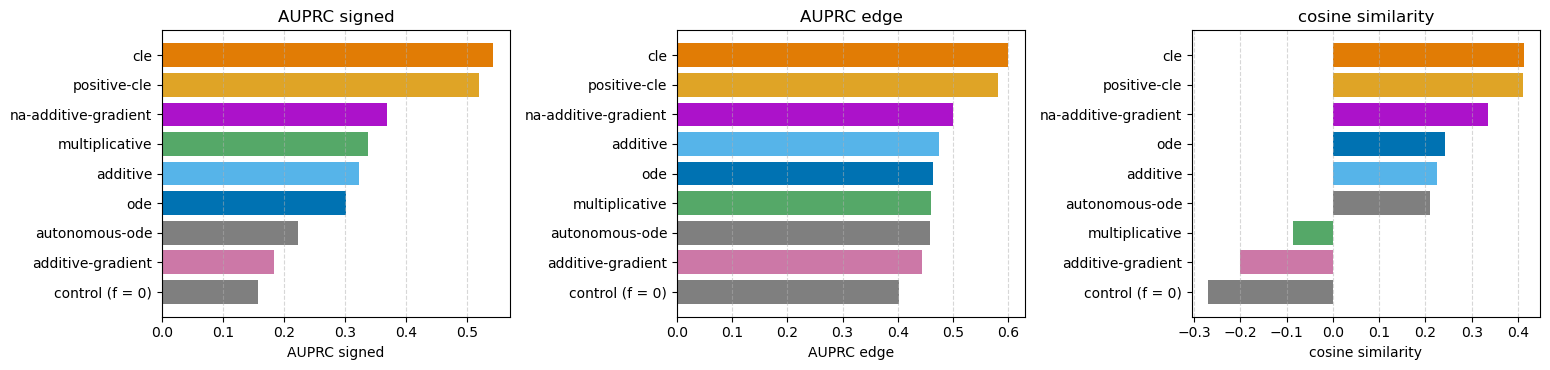

In [16]:
# AUPRC and cosine metrics ranking (same style as interpolation error)

metric_dicts = {
    'AUPRC signed': {name: vals['AP_signed'] for name, vals in auprc_scores.items()},
    'AUPRC edge': {name: vals['AP_edge'] for name, vals in auprc_scores.items()},
    'cosine similarity': cosine_similarity,
}

fig, axes = plt.subplots(1, 3, figsize=(15.6, 3.8), sharey=False)

for ax, (metric_name, metric_dict) in zip(axes, metric_dicts.items()):
    sorted_items = sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)
    methods_sorted, values_sorted = zip(*sorted_items)
    colors_sorted = [base_colors.get(m, '#7F7F7F') for m in methods_sorted]

    ax.barh(methods_sorted, values_sorted, color=colors_sorted)
    ax.invert_yaxis()
    ax.set_xlabel(metric_name)
    ax.set_title(f'{metric_name}')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [10]:
# Load Kaggle multiome data and keep HSC/HSPC cells at first time point
nsamples_kaggle = 16000

samples_kaggle, times_kaggle, ind_array_kaggle, cell_types_kaggle = load_data(
    "kaggle",
    nsamples=nsamples_kaggle,
    genes=genes,
    time_key='day',
    cell_type_key='cell_type',
    seed=seed,
    max_tot_counts=200,
    normalize=False,
)

kaggle_categories = list(cell_types_kaggle.cat.categories)
kaggle_ct_to_int = {ct: i for i, ct in enumerate(kaggle_categories)}
hsc_code = kaggle_ct_to_int['HSPC']
ind_hsc0 = np.where(ind_array_kaggle[0] == hsc_code)[0]
HSC_kaggle = samples_kaggle[0, ind_hsc0, :ndim]

print('Kaggle times:', times_kaggle)
print('Kaggle categories:', kaggle_categories)
print('HSPC/HSC cells at first kaggle time:', HSC_kaggle.shape[0])




[fetch] using cached file: /mnt/home/vchardes/pfi_data/CITE-seq_10.1126_science.adi8577_GSE305370.h5ad


[load_data] removed 12 cells outside total-count range [0.0, 200] (0.01% of total cells) before subsampling.
['B cell', 'Erythroid cell', 'Granulocyte monocyte progenitor', 'HSPC', 'MEMP', 'Megakaryocyte', 'Megakaryocyte progenitor cell', 'Monocyte', 'Myeloid progenitor', 'Mast', 'Basophil', 'Eosinophil']
Kaggle times: [ 2  3  4  7 10]
Kaggle categories: ['B cell', 'Erythroid cell', 'Granulocyte monocyte progenitor', 'HSPC', 'MEMP', 'Megakaryocyte', 'Megakaryocyte progenitor cell', 'Monocyte', 'Myeloid progenitor', 'Mast', 'Basophil', 'Eosinophil']
HSPC/HSC cells at first kaggle time: 10079


In [11]:
# Run inferred models from kaggle HSC at first time to last kaggle time
t0_kaggle = float(times_kaggle[0])#float(times_kaggle[0])
tT_kaggle = float(times_kaggle[-1])
X0_kaggle = np.hstack([HSC_kaggle, t0_kaggle * np.ones((HSC_kaggle.shape[0], 1))])

gen_kaggle_last = {}
for model_name, reg in flow_regs.items():
    gen_kaggle_last[model_name] = reg.sample(
        X0_kaggle,
        Dt = 1*float(times_kaggle[-1] - times_kaggle[0]),
        stoch=True,
        dt=0.005,
        pos=True,
    )


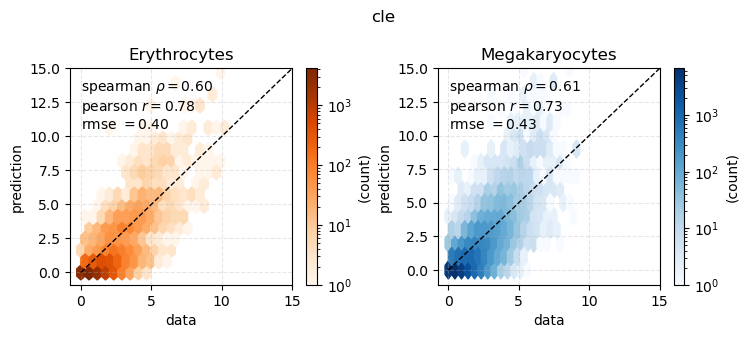

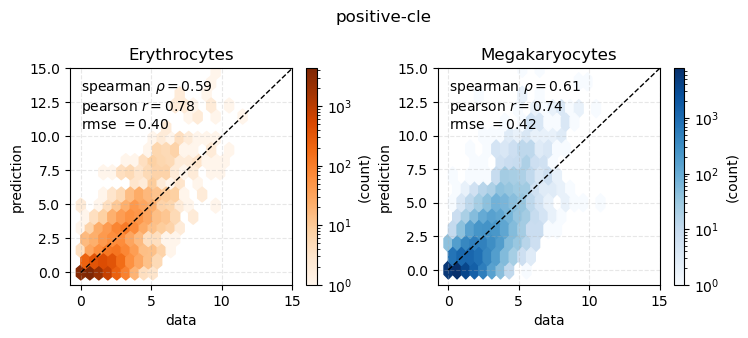

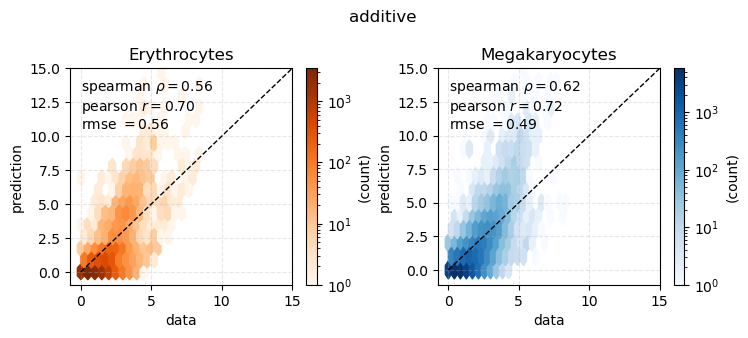

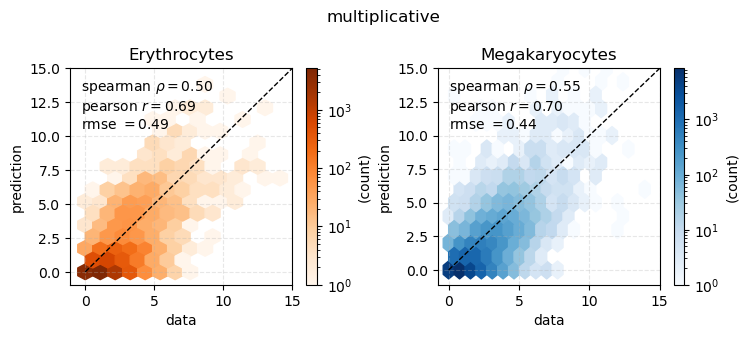

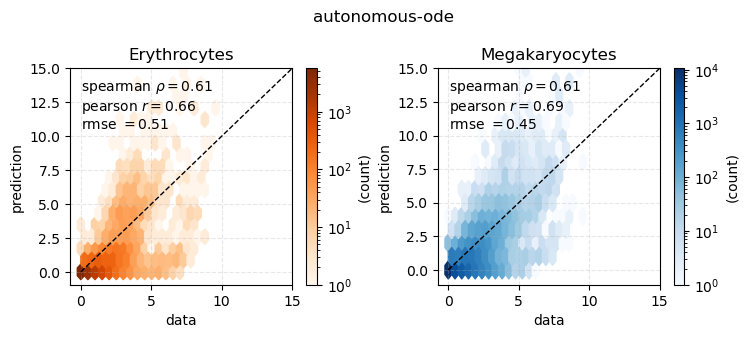

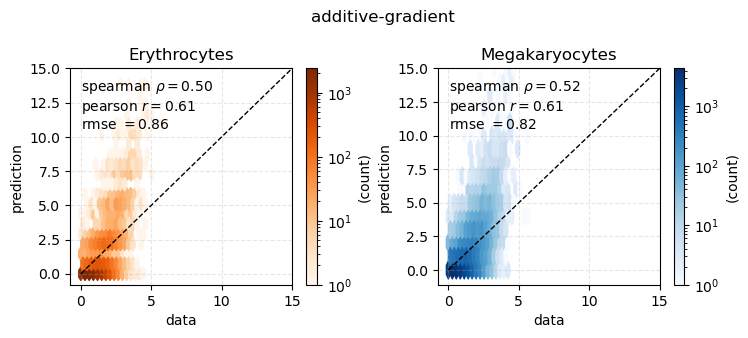

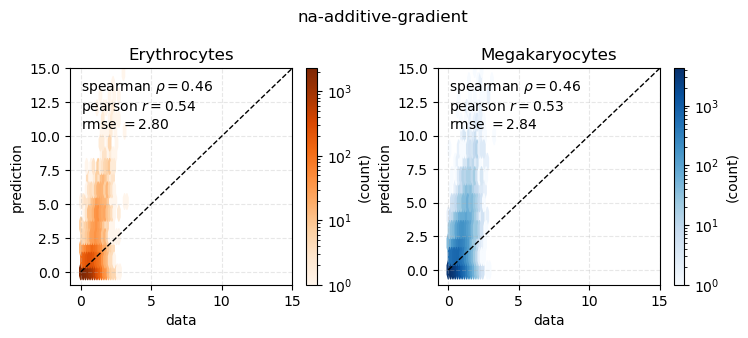

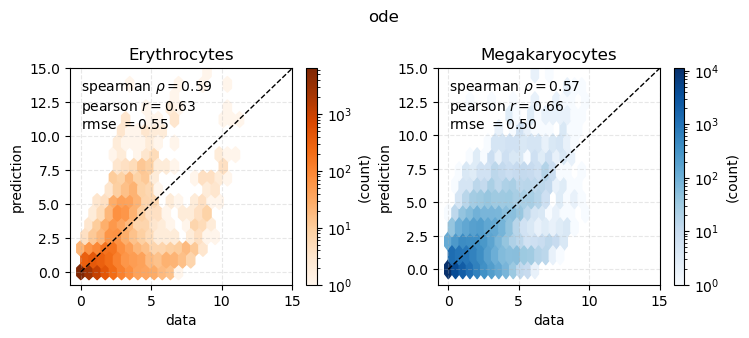

In [12]:
# Final-time generalization: per-model hexbin + correlation computation
import matplotlib.pyplot as plt
from pfi.utils.data import assign_OT, compute_correlations

train_categories = list(cell_types.cat.categories)
train_ct_to_int = {ct: i for i, ct in enumerate(train_categories)}
ind_Ery = np.where((ind_array[-1,] == train_ct_to_int['Ery1']) | (ind_array[-1,] == train_ct_to_int['Ery2']))[0]
ind_Meg = np.where((ind_array[-1,] == train_ct_to_int['Mk1']) | (ind_array[-1,] == train_ct_to_int['Mk2']))[0]
groups = {'erythrocytes': ind_Ery, 'megakaryocytes': ind_Meg}

train_last = samples[-1, :, :ndim]
comparison = {}
xmax = 15
ymax = 15
nmax = 2000
sym = False
for model_name in flow_regs.keys():
    x_ref_test, y_test, _, j_test = assign_OT(
        gen_kaggle_last[model_name][0:nmax, :ndim],
        train_last,
        return_indices=True,
        sym=sym,
    )
    x_ref_train, y_train, _, j_train = assign_OT(
        gen_natcomm_last[model_name][0:nmax, :ndim],
        train_last,
        return_indices=True,
        sym=sym
    )

    comparison[model_name] = {}
    for group_name, inds in groups.items():
        mask_test = np.isin(j_test, inds)
        mask_train = np.isin(j_train, inds)
        comparison[model_name][group_name] = {
            'test': compute_correlations(x_ref_test[mask_test], y_test[mask_test]),
            'train': compute_correlations(x_ref_train[mask_train], y_train[mask_train]),
        }

    fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.4))
    for ax, (group_name, inds, label, cmap_) in zip(
        axes,
        [
            ('erythrocytes', ind_Ery, 'Erythrocytes', 'Oranges'),
            ('megakaryocytes', ind_Meg, 'Megakaryocytes', 'Blues'),
        ],
    ):
        mask_test = np.isin(j_test, inds)

        all_xt = x_ref_test[mask_test].reshape(-1)
        all_xtp1 = y_test[mask_test].reshape(-1)

        hb = ax.hexbin(all_xt, all_xtp1, gridsize=20, cmap=cmap_, bins='log')
        cb = fig.colorbar(hb, ax=ax)
        cb.set_label('(count)')

        metrics = comparison[model_name][group_name]['test']
        ax.plot([0, xmax], [0, ymax], 'k--', lw=1)
        ax.set_xlim(xmax=xmax)
        ax.set_ylim(ymax=ymax)
        ax.set_xlabel('data')
        ax.set_ylabel('prediction')
        ax.set_title(label)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.text(
            0.05,
            0.95,
            rf"spearman $\rho = {metrics['spearman']:.2f}$"
            + "\n"
            + rf"pearson $r = {metrics['pearson']:.2f}$"
            + "\n"
            + rf"rmse $= {metrics['rmse_l2']:.2f}$",
            transform=ax.transAxes,
            ha='left',
            va='top',
        )
        
    fig.suptitle(model_name)
    plt.tight_layout()
    plt.show()


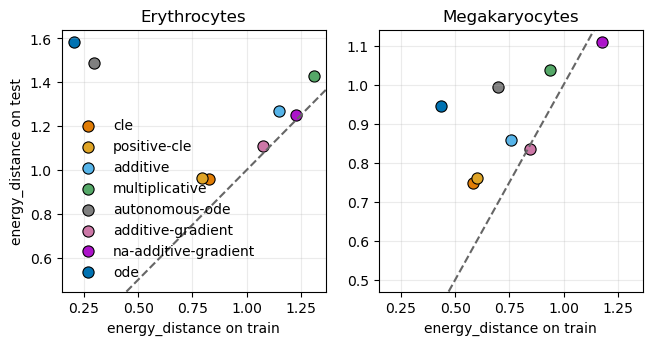

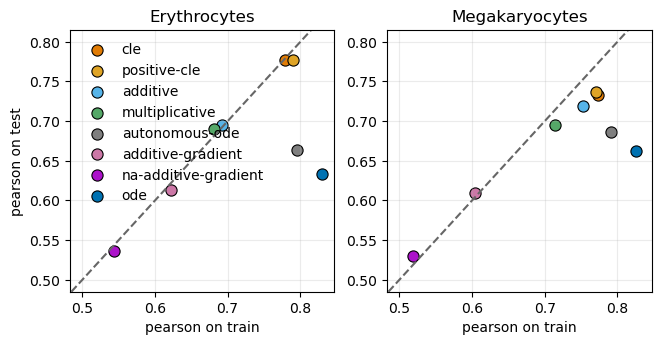

In [21]:
metrics = ['energy_distance', 'pearson']
for metric in metrics:
    group_specs = [
        ('erythrocytes', 'Erythrocytes'),
        ('megakaryocytes', 'Megakaryocytes'),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.4), sharex=True)

    for ax, (group_name, title) in zip(axes, group_specs):
        for model_name, scores in comparison.items():
            cfg = base_colors.get(model_name)
            ax.scatter(
                scores[group_name]['train'][metric],
                scores[group_name]['test'][metric],
                c=cfg,
                marker='o',
                edgecolor='k',
                s=65,
                linewidth=0.8,
                label=model_name,
            )

        ax.axline((0.5, 0.5), (0.8, 0.8), linestyle='--', color='0.4')

        ax.set_title(title)
        ax.set_xlabel(metric + ' on train')
        ax.grid(alpha=0.25)

    axes[0].legend(frameon=False)
    axes[0].set_ylabel(metric + ' on test')
    plt.show()
